In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph , START , END

In [2]:
class AgentState(TypedDict):
    number1  : int
    number2  : int
    number3  : int
    number4  : int
    operation1 : str
    operation2 : str
    final1 : int
    final2 : int


    


In [7]:
def adder1(state : AgentState) -> AgentState:
    """this is the adder node"""
    state['final1'] =  state['number1'] + state['number2'] 
    return state

def subtractor1(state : AgentState) -> AgentState:
    state['final1'] = state['number1'] - state['number2']
    return state

def decide_next_node1(state : AgentState) -> AgentState:
    if state['operation1'] == "+":
     return "addition_operation"
    elif state['operation1'] == "-":
       return "subtraction_operation"
    
    
    



In [6]:
def adder2(state : AgentState) -> AgentState:
    """this is the adder node"""
    state['final2'] =  state['number3'] + state['number4'] 
    return state

def subtractor2(state : AgentState) -> AgentState:
    state['final1'] = state['number3'] - state['number4']
    return state

def decide_next_node2(state : AgentState) -> AgentState:
    if state['operation1'] == "+":
     return "addition_operation1"
    elif state['operation1'] == "-":
       return "subtraction_operation2"

In [14]:
graph = StateGraph(AgentState)

graph.add_node("adder1" , adder1)
graph.add_node("adder2" , adder2)
graph.add_node("subtractor1" ,subtractor1 )
graph.add_node("subtractor2" ,subtractor2 )
graph.add_node("router1" , lambda state:state)
graph.add_node("router2" , lambda state:state)

graph.add_edge(START , "router1")

graph.add_conditional_edges(
    "router1" ,
    decide_next_node1, 
    {
        "addition_operation" : "adder1",
        "subtraction_operation":"subtractor1"
    }
)
graph.add_edge("adder1" ,"router2" )
graph.add_edge("subtractor1" ,"router2" )
graph.add_conditional_edges(
    "router2" ,
    decide_next_node2, 
    {
        "addition_operation1" : "adder2",
        "subtraction_operation2":"subtractor2"
    }
)

graph.add_edge( "adder2", END )
graph.add_edge("subtractor2" , END)

# fix: add correctly named node (removed trailing space) so edges reference a known node


app = graph.compile()

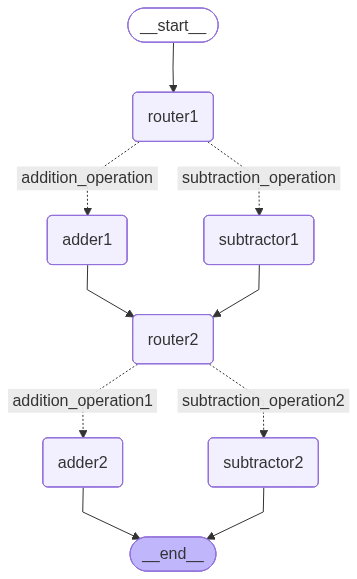

In [15]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))